In [1]:
#!python --version # 3.11

In [2]:
#!pip install "iqm-client[qiskit]"==34.0.2

In [3]:
#!pip install pylatexenc

In [4]:
#!pip install matplotlib

In [5]:
from iqm import qiskit_iqm
from fake_vlq_2026_05_25 import FakeVLQ

In [6]:
backendFakeVLQ = FakeVLQ()

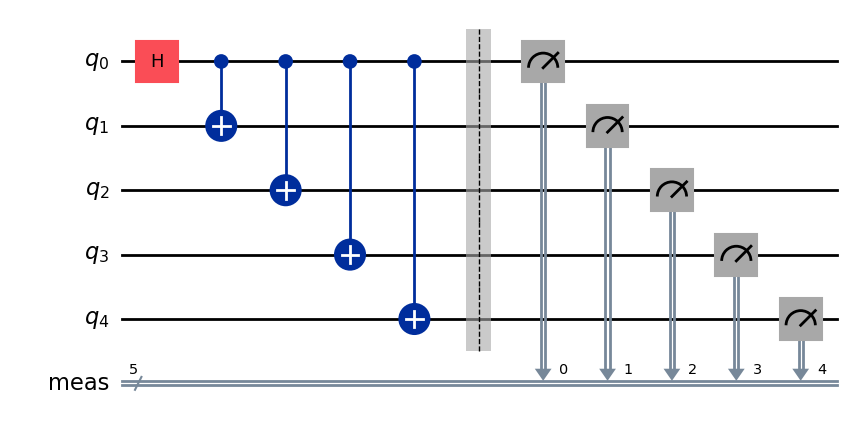

In [7]:
from qiskit import QuantumCircuit

# Define quantum circuit
num_qb = 5
qc = QuantumCircuit(num_qb)

qc.h(0)
for qb in range(0, num_qb-1):
    qc.cx(0,qb+1)
    
qc.measure_all()

qc.draw(output='mpl')

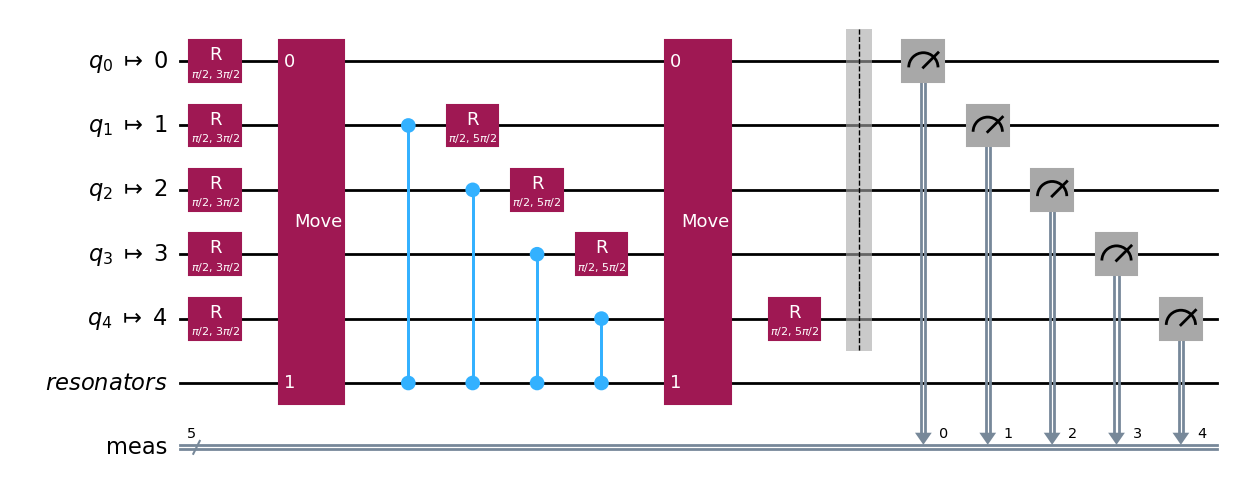

In [8]:
from iqm.qiskit_iqm import  transpile_to_IQM

# Transpile circuit
qc_transpiled = transpile_to_IQM(qc, backendFakeVLQ)
qc_transpiled.draw(output="mpl", idle_wires=False, fold=-1)

{'01010': 3, '11000': 4, '10101': 7, '11101': 187, '11100': 12, '10010': 8, '01111': 238, '10000': 148, '00001': 143, '00110': 28, '01110': 56, '11110': 203, '00010': 161, '11011': 133, '11111': 3898, '00100': 85, '10001': 15, '00101': 5, '01001': 3, '11010': 5, '10110': 7, '00111': 9, '00011': 9, '00000': 4303, '11001': 20, '01101': 15, '10011': 4, '01011': 3, '01000': 93, '01100': 7, '10111': 182, '10100': 6}


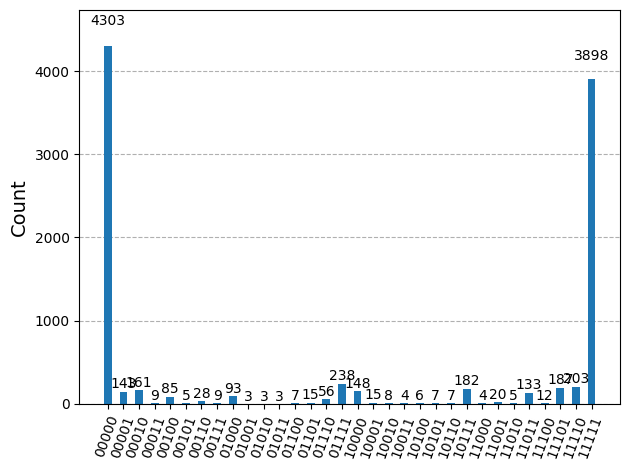

In [9]:
from qiskit.visualization import plot_histogram

# Run circuit
SHOTS = 10000
job = backendFakeVLQ.run(qc_transpiled, shots=SHOTS)
counts = job.result().get_counts()
print(counts)
plot_histogram(counts)